In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import time

df_long_raw = pd.read_csv("all_reaction_data_w_metadata_unrolled_20260222.csv")

dedupe_keys = ["source_folder", "solutionCategory", "problemCategory", "reaction_class"]
missing = [c for c in dedupe_keys if c not in df_long_raw.columns]
if missing:
    raise ValueError(f"Missing dedupe key columns: {missing}")

n_before = len(df_long_raw)
all_data = df_long_raw.drop_duplicates(subset=dedupe_keys, keep="first").copy()
n_after = len(all_data)
n_dropped = n_before - n_after

print(f"Loaded rows: {n_before:,}")
print(f"After dedupe on {dedupe_keys}: {n_after:,}")
print(f"Dropped duplicates: {n_dropped:,}")

Loaded rows: 27,392
After dedupe on ['source_folder', 'solutionCategory', 'problemCategory', 'reaction_class']: 21,878
Dropped duplicates: 5,514


In [12]:
import sys
sys.path.append("..")
from figure4_new2.figure4_helper import pretty_label, pretty_rxn_label, wrap_label, nlines


In [ ]:
# 7-level Sankey: reaction_class >> rxnSubcategory >> rxnCategory >> problemCategory >> solutionCat_L1 >> solutionCat_L2 >> solution_category
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Use existing DataFrame if present; otherwise reload
if "all_data" not in globals():
    all_data = pd.read_csv("all_reaction_data_w_metadata_unrolled_20260222.csv")

# Some files use solutionCategory instead of solution_category
if "solution_category" not in all_data.columns and "solutionCategory" in all_data.columns:
    all_data = all_data.copy()
    all_data["solution_category"] = all_data["solutionCategory"]

flow_cols = [
    "reaction_class",
    "rxnSubcategory",
    "rxnCategory",
    "problemCategory",
    "solutionCat_L1",
    "solutionCat_L2",
    "solution_category",
]

missing = [c for c in flow_cols if c not in all_data.columns]
if missing:
    raise ValueError(f"Missing required columns for Sankey: {missing}")

# Optional: keep only top N most abundant reaction classes.
# Set to None to keep all reaction classes.
top_n_reaction_classes = 50

# Keep rows with complete path
df_flow = all_data[flow_cols].dropna().copy()
for col in flow_cols:
    df_flow[col] = df_flow[col].astype(str).str.strip()
df_flow = df_flow[(df_flow[flow_cols] != "").all(axis=1)].copy()

if top_n_reaction_classes is not None:
    top_classes = (
        df_flow["reaction_class"]
        .value_counts()
        .head(int(top_n_reaction_classes))
        .index
    )
    df_flow = df_flow[df_flow["reaction_class"].isin(top_classes)].copy()
    print(f"Top N reaction classes enabled: {int(top_n_reaction_classes)}")
    print(f"Unique reaction classes kept: {len(top_classes)}")

total_count = len(df_flow)
print(f"Rows used in Sankey: {total_count}")

# Build weighted edges between adjacent levels
edges = []
for i in range(len(flow_cols) - 1):
    src_col = flow_cols[i]
    tgt_col = flow_cols[i + 1]
    agg = (
        df_flow.groupby([src_col, tgt_col], dropna=False)
        .size()
        .reset_index(name="value")
    )
    agg["level_src"] = src_col
    agg["level_tgt"] = tgt_col
    agg = agg.rename(columns={src_col: "src", tgt_col: "tgt"})
    edges.append(agg[["level_src", "level_tgt", "src", "tgt", "value"]])

edges_df = pd.concat(edges, ignore_index=True)

# Node IDs include level to avoid label collisions across levels
node_labels = []
node_raw_labels = []
node_ids = []
node_hover = []
node_index = {}

def format_label_for_level(level: str, label: str) -> str:
    if level in ["reaction_class", "rxnSubcategory", "rxnCategory"]:
        return pretty_rxn_label(label)
    return pretty_label(label)

def add_node(level: str, label: str) -> int:
    node_id = f"{level}::{label}"
    if node_id not in node_index:
        node_index[node_id] = len(node_labels)
        node_ids.append(node_id)
        node_raw_labels.append(label)
        node_labels.append(format_label_for_level(level, label))
        node_hover.append(f"{level}: {label}")
    return node_index[node_id]

source_indices = []
target_indices = []
values = []

for _, row in edges_df.iterrows():
    s = add_node(row["level_src"], row["src"])
    t = add_node(row["level_tgt"], row["tgt"])
    source_indices.append(s)
    target_indices.append(t)
    values.append(int(row["value"]))

# Add per-node frequency/count to displayed labels
n_nodes = len(node_labels)
incoming = np.zeros(n_nodes, dtype=int)
outgoing = np.zeros(n_nodes, dtype=int)
for s, t, v in zip(source_indices, target_indices, values):
    outgoing[s] += int(v)
    incoming[t] += int(v)
node_counts = np.maximum(incoming, outgoing)
node_labels = [
    f"{format_label_for_level(nid.split('::', 1)[0], lbl)} ({int(cnt)})"
    for nid, lbl, cnt in zip(node_ids, node_raw_labels, node_counts)
]

# Monochrome fills similar to your Figure 4 Sankey cell
level_color = {
    "reaction_class": "black",
    "rxnSubcategory": "#2F2F2F",
    "rxnCategory": "#3A3A3A",
    "problemCategory": "#555555",
    "solutionCat_L1": "#666666",
    "solutionCat_L2": "#888888",
    "solution_category": "#AAAAAA",
}

def node_color(node_id: str) -> str:
    lvl = node_id.split("::", 1)[0]
    return level_color.get(lvl, "#AAAAAA")

node_colors = [node_color(nid) for nid in node_ids]
max_val = max(values) if values else 1

def link_color(v: int) -> str:
    intensity = max(40, 180 - int(140 * (v / max_val)))
    return f"rgba({intensity},{intensity},{intensity},0.7)"

link_colors = [link_color(v) for v in values]

# -----------------------------------------------------------------
# Custom border colormap for the last 3 columns
# solutionCat_L1, solutionCat_L2, solution_category
# -----------------------------------------------------------------
def build_solution_color_map(
    solution_categories,
    cat_to_L1L2,
    cmaps=None,
    alpha_range=(0.65, 0.95),
    span=(0.50, 0.90),
):
    """
    - L1: different colormap family
    - L2: discrete steps within that L1 cmap
    - alpha: increases with index within L1 for extra separability
    """
    if cmaps is None:
        cmaps = ["YlOrRd", "RdPu", "winter", "copper", "cool"]

    l1_to_cats = {}
    for cat in solution_categories:
        l1, l2 = cat_to_L1L2[cat]
        l1_to_cats.setdefault(l1, []).append(cat)

    for l1 in l1_to_cats:
        l1_to_cats[l1].sort(key=lambda c: (cat_to_L1L2[c][1], c))

    solution_color_map = {}
    l1s = sorted(l1_to_cats.keys())

    lo, hi = span
    a0, a1 = alpha_range

    for j, l1 in enumerate(l1s):
        cats = l1_to_cats[l1]
        n = len(cats)

        cmap = plt.get_cmap(cmaps[j % len(cmaps)], n)
        _ = np.linspace(lo, hi, n)
        alphas = np.linspace(a0, a1, n)

        for i, cat in enumerate(cats):
            rgb = cmap(i)[:3]
            solution_color_map[cat] = (*rgb, float(alphas[i]))

    return solution_color_map

def rgba_tuple_to_css(rgba):
    r, g, b, a = rgba
    return f"rgba({int(round(r*255))},{int(round(g*255))},{int(round(b*255))},{float(a):.3f})"

# Build category -> (L1, L2) mapping from current filtered data
cat_to_L1L2 = (
    df_flow[["solution_category", "solutionCat_L1", "solutionCat_L2"]]
    .drop_duplicates()
    .set_index("solution_category")[["solutionCat_L1", "solutionCat_L2"]]
    .to_dict("index")
)
cat_to_L1L2 = {k: (v["solutionCat_L1"], v["solutionCat_L2"]) for k, v in cat_to_L1L2.items()}

solution_categories = sorted(cat_to_L1L2.keys())
solution_color_map = build_solution_color_map(solution_categories, cat_to_L1L2)

# Roll up solution-category colors to L2 and L1 border colors (mean rgba)
l2_to_rgba = {}
l1_to_rgba = {}
for l1, l2 in set(cat_to_L1L2.values()):
    cats_l2 = [c for c in solution_categories if cat_to_L1L2[c] == (l1, l2)]
    if cats_l2:
        arr = np.array([solution_color_map[c] for c in cats_l2], dtype=float)
        l2_to_rgba[l2] = tuple(arr.mean(axis=0).tolist())

for l1 in sorted({v[0] for v in cat_to_L1L2.values()}):
    cats_l1 = [c for c in solution_categories if cat_to_L1L2[c][0] == l1]
    if cats_l1:
        arr = np.array([solution_color_map[c] for c in cats_l1], dtype=float)
        l1_to_rgba[l1] = tuple(arr.mean(axis=0).tolist())

default_border = "rgba(0,0,0,0.35)"
node_border_colors = []
for nid in node_ids:
    lvl, label = nid.split("::", 1)
    if lvl == "solution_category" and label in solution_color_map:
        node_border_colors.append(rgba_tuple_to_css(solution_color_map[label]))
    elif lvl == "solutionCat_L2" and label in l2_to_rgba:
        node_border_colors.append(rgba_tuple_to_css(l2_to_rgba[label]))
    elif lvl == "solutionCat_L1" and label in l1_to_rgba:
        node_border_colors.append(rgba_tuple_to_css(l1_to_rgba[label]))
    else:
        node_border_colors.append(default_border)

# Sizing/typography similar to prior Sankey setup
dpi = 300 / 5
width_px = int(7.2 * dpi)
height_px = int(6 * dpi)
font_size_px = int(6 / 72 * dpi) * 0.6

fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",
            node=dict(
                align="center",
                pad=10,
                thickness=15,
                line=dict(color=node_border_colors, width=1.25),
                label=node_labels,
                color=node_colors,
                customdata=node_hover,
                hovertemplate="%{customdata}<extra></extra>",
            ),
            link=dict(
                source=source_indices,
                target=target_indices,
                value=values,
                color=link_colors,
                hovertemplate="Count: %{value}<extra></extra>",
            ),
        )
    ]
)

fig.update_layout(
    title=dict(
        text=f"Reaction → Subcategory → Category → Problem → Solution Taxonomy Sankey ({total_count})",
        font=dict(size=font_size_px, color="black"),
        x=0.5,
        xanchor="center",
    ),
    font=dict(size=font_size_px, color="black"),
    plot_bgcolor="white",
    paper_bgcolor="white",
    width=width_px,
    height=height_px,
    margin=dict(l=30, r=30, t=60, b=30),
)

# fig.show()
# Optional export:
# fig.write_image("scaleup_sankey_indexed2.svg", width=width_px, height=height_px, scale=2)

# fig.write_image("sankey_reaction_problem_solution.png", width=width_px, height=height_px, scale=2)

Top N reaction classes enabled: 50
Unique reaction classes kept: 50
Rows used in Sankey: 19429


In [10]:
# Circular hierarchical tree + links using pyCircos (API-correct)
# Layers (inner -> outer):
# rxnCategory -> rxnSubcategory -> reaction_class -> problemCategory -> solutionCat_L1 -> solutionCat_L2 -> solution_category

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Robust pyCircos imports (different environments can expose symbols differently)
try:
    import pycircos as _pycircos
except Exception as _e:
    raise ImportError(
        "Could not import module 'pycircos'. Install the package 'python-circos' and restart the kernel."
    ) from _e

try:
    if hasattr(_pycircos, "Gcircle") and hasattr(_pycircos, "Garc"):
        Gcircle = _pycircos.Gcircle
        Garc = _pycircos.Garc
    else:
        from pycircos.pycircos import Gcircle, Garc
except Exception as _e:
    raise ImportError(
        f"Imported 'pycircos' from {getattr(_pycircos, '__file__', 'unknown')}, "
        "but it does not expose pyCircos classes (Gcircle/Garc). "
        "This usually means a different package with the same module name is installed. "
        "Install 'python-circos' and restart kernel."
    ) from _e

# Reuse loaded dataframe if present
if "all_data" not in globals():
    all_data = pd.read_csv("all_reaction_data_w_metadata_unrolled_20260222.csv")

# Normalize possible column alias
if "solution_category" not in all_data.columns and "solutionCategory" in all_data.columns:
    all_data = all_data.copy()
    all_data["solution_category"] = all_data["solutionCategory"]


Rows used for tree: 27392
Outer problem ring sections: 11


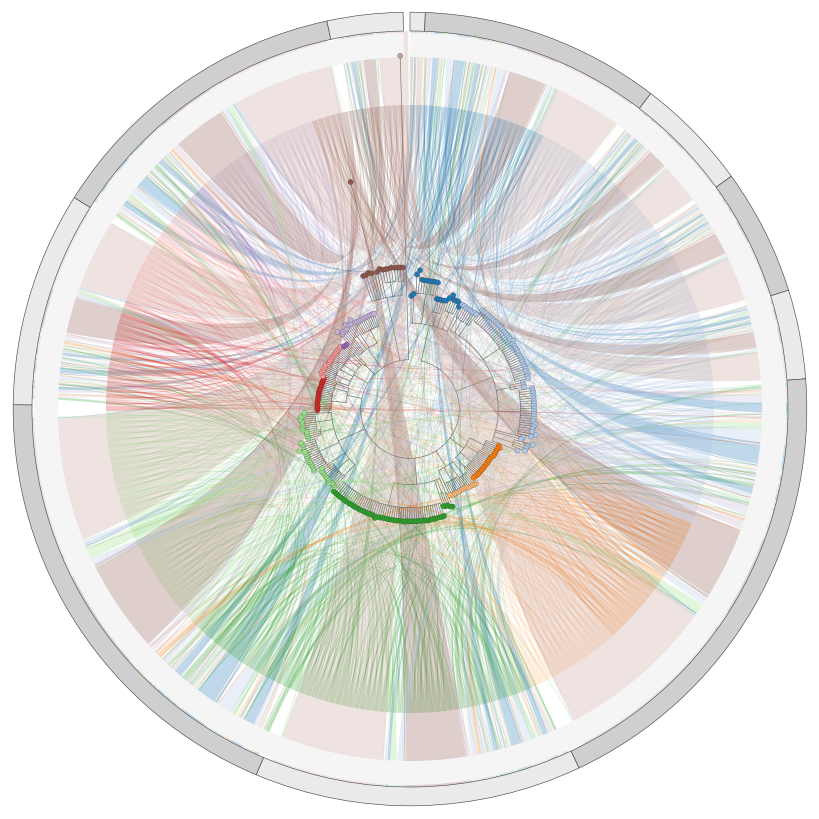

In [28]:
# Styled circular phylogenetic tree from hierarchy:
# inner -> outer: rxnCategory -> rxnSubcategory -> reaction_class
# branch lengths are proportional to observed frequencies

import math
import re
import tempfile
from collections import defaultdict

import matplotlib.pyplot as plt
import pandas as pd

# Robust pyCirCos imports (python-circos package)
try:
    import pycircos as _pycircos
except Exception as _e:
    raise ImportError(
        "Could not import module 'pycircos'. Install package 'python-circos' and restart kernel."
    ) from _e

try:
    import pycircos.tree as _pctree
    if hasattr(_pycircos, "Tcircle") and hasattr(_pycircos, "Tarc"):
        Tcircle = _pycircos.Tcircle
        Tarc = _pycircos.Tarc
    else:
        from pycircos.tree import Tcircle, Tarc
except Exception as _e:
    raise ImportError(
        f"Imported module at {getattr(_pycircos, '__file__', 'unknown')} but could not load Tcircle/Tarc. "
        "This usually indicates a different package named 'pycircos'."
    ) from _e

# Patch known pyCircos bug: Tarc._get_col_positions refers to module-global `tree`
def _get_col_positions_fixed(self):
    taxa = self.tree.get_terminals()
    max_label_width = max([len(str(t)) for t in taxa]) if len(taxa) > 0 else 1
    drawing_width = 100 - max_label_width - 1

    depths = self.tree.depths()
    if len(depths) == 0:
        self._col_positions = {}
        return

    if max(depths.values()) == 0:
        depths = self.tree.depths(unit_branch_lengths=True)

    fudge_margin = math.log(max(len(taxa), 2), 2)
    max_depth = float(max(depths.values())) if max(depths.values()) != 0 else 1.0
    cols_per_branch_unit = (drawing_width - fudge_margin) / max_depth

    for clade in list(depths.keys()):
        depths[clade] = depths[clade] * cols_per_branch_unit + fudge_margin

    self._col_positions = depths

_pctree.Tarc._get_col_positions = _get_col_positions_fixed

# Data prep
if "all_data" not in globals():
    all_data = pd.read_csv("all_reaction_data_w_metadata_unrolled_20260222.csv")

tree_cols = ["rxnCategory", "rxnSubcategory", "reaction_class"]
missing = [c for c in tree_cols if c not in all_data.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df_tree = all_data[tree_cols].dropna().copy()
for c in tree_cols:
    df_tree[c] = df_tree[c].astype(str).str.strip()
df_tree = df_tree[(df_tree[tree_cols] != "").all(axis=1)].copy()
print(f"Rows used for tree: {len(df_tree)}")

# Frequency tables for branch-length scaling
cat_counts = df_tree.groupby(["rxnCategory"]).size().to_dict()
sub_counts = df_tree.groupby(["rxnCategory", "rxnSubcategory"]).size().to_dict()
cls_counts = df_tree.groupby(["rxnCategory", "rxnSubcategory", "reaction_class"]).size().to_dict()

max_count = max(
    max(cat_counts.values()) if cat_counts else 1,
    max(sub_counts.values()) if sub_counts else 1,
    max(cls_counts.values()) if cls_counts else 1,
)

def _branch_len(count_value: int, min_len: float = 0.4, span: float = 2.6) -> float:
    return float(min_len + span * (count_value / max_count))

# Hierarchy map
hier = defaultdict(lambda: defaultdict(set))
for _, row in df_tree.drop_duplicates().iterrows():
    hier[row["rxnCategory"]][row["rxnSubcategory"]].add(row["reaction_class"])

# Safe / unique label helpers
def _safe_label(text: str) -> str:
    text = text.strip()
    text = re.sub(r"[\s]+", "_", text)
    text = re.sub(r"[^A-Za-z0-9_\-\.]+", "_", text)
    return text if text else "unknown"

seen = defaultdict(int)
def _uniq(level: str, raw: str) -> str:
    base = f"{level}_{_safe_label(raw)}"
    seen[base] += 1
    return base if seen[base] == 1 else f"{base}_{seen[base]}"

# Build weighted Newick (root->category->subcategory->reaction_class)
cat_parts = []
leaf_to_cat = {}
leaf_to_path = {}
path_to_leaf = {}
for cat in sorted(hier.keys()):
    cat_label = _uniq("cat", cat)
    sub_parts = []
    for sub in sorted(hier[cat].keys()):
        sub_label = _uniq("sub", sub)
        leaf_parts = []
        for cls in sorted(hier[cat][sub]):
            leaf_label = _uniq("cls", cls)
            leaf_to_cat[leaf_label] = cat
            leaf_to_path[leaf_label] = (cat, sub, cls)
            path_to_leaf[(cat, sub, cls)] = leaf_label
            l_cls = _branch_len(cls_counts[(cat, sub, cls)])
            leaf_parts.append(f"{leaf_label}:{l_cls:.4f}")

        l_sub = _branch_len(sub_counts[(cat, sub)])
        sub_parts.append(f"({','.join(leaf_parts)}){sub_label}:{l_sub:.4f}")

    l_cat = _branch_len(cat_counts[cat])
    cat_parts.append(f"({','.join(sub_parts)}){cat_label}:{l_cat:.4f}")

newick_str = f"({','.join(cat_parts)})rxn_root;"

with tempfile.NamedTemporaryFile("w", suffix=".nwk", delete=False) as tmp:
    tmp.write(newick_str)
    tree_path = tmp.name

# Example-like styling: colored tip points + cleaner tree lines
unique_cats = sorted(set(leaf_to_cat.values()))
palette = plt.cm.tab20.colors
cat_color = {cat: palette[i % len(palette)] for i, cat in enumerate(unique_cats)}

cladevisual_dict = {}
for leaf_label, cat in leaf_to_cat.items():
    cladevisual_dict[leaf_label] = {
        "color": cat_color[cat],
        "size": 14,
        "linewidth": 0.15,
        "edgecolor": "#303030",
    }

# Draw
tcircle = Tcircle(figsize=(6, 6))
tarc = Tarc(
    arc_id="rxn_tree",
    tree=tree_path,
    format="newick",
    interspace=1,
    raxis_range=(880, 940),
    facecolor="#F5F5F5",
    edgecolor="#A0A0A0",
    linewidth=0,
    label="rxnCategory > rxnSubcategory > reaction_class",
    label_visible=False,
)

tcircle.add_tarc(tarc)
tcircle.set_tarcs()

# Outward tree so depth increases from center to outer ring
tcircle.plot_tree(
    tarc.arc_id,
    rlim=(0, 760),
    cladevisual_dict=cladevisual_dict,
    linewidth=0.45,
    linecolor="#606060",
)

# Add outer segmented arc: segment angular size proportional to problemCategory count
problem_segment_ranges = {}
if "problemCategory" in all_data.columns:
    link_cols = ["rxnCategory", "rxnSubcategory", "reaction_class", "problemCategory"]
    df_links = all_data[link_cols].dropna().copy()
    for c in link_cols:
        df_links[c] = df_links[c].astype(str).str.strip()
    df_links = df_links[(df_links[link_cols] != "").all(axis=1)].copy()

    problem_counts = df_links["problemCategory"].value_counts().sort_index()
    problem_classes = problem_counts.index.tolist()
    n_problem = len(problem_classes)

    if n_problem > 0:
        total_problem = float(problem_counts.sum())
        arc_size = float(tarc.size)

        # Convert counts -> arc coordinate widths (sum == tarc.size)
        widths = [(problem_counts[p] / total_problem) * arc_size for p in problem_classes]
        starts = []
        cursor = 0.0
        for w in widths:
            starts.append(cursor)
            cursor += w

        # Force exact closure on last segment
        if widths:
            widths[-1] += max(0.0, arc_size - sum(widths))

        for p, s, w in zip(problem_classes, starts, widths):
            problem_segment_ranges[p] = (s, s + w)

        problem_data = [1.0] * n_problem
        problem_colors = ["#EAEAEA" if i % 2 == 0 else "#CFCFCF" for i in range(n_problem)]

        tcircle.barplot(
            tarc.arc_id,
            data=problem_data,
            positions=starts,
            width=widths,
            raxis_range=(945, 992),
            rlim=(0, 1),
            base_value=0,
            facecolor=problem_colors,
            edgecolor="#4A4A4A",
            linewidth=0.45,
        )

        print(f"Outer problem ring sections: {n_problem}")

        # Draw links from reaction leaves to associated problems
        # Aggregate by exact tree path to avoid label collision issues
        edge_counts = (
            df_links.groupby(["rxnCategory", "rxnSubcategory", "reaction_class", "problemCategory"])
            .size()
            .reset_index(name="count")
        )

        edges = []
        for _, row in edge_counts.iterrows():
            path = (row["rxnCategory"], row["rxnSubcategory"], row["reaction_class"])
            leaf = path_to_leaf.get(path)
            prob = row["problemCategory"]
            if leaf is None or prob not in problem_segment_ranges:
                continue
            edges.append((leaf, prob, int(row["count"])))

        if edges:
            edge_df = pd.DataFrame(edges, columns=["leaf", "problem", "count"])
            leaf_tot = edge_df.groupby("leaf")["count"].sum().to_dict()
            prob_tot = edge_df.groupby("problem")["count"].sum().to_dict()

            # Leaf coordinate ranges along tarc arc (one slot per terminal)
            terminal_order = list(tarc.terminal_dict.keys())
            leaf_ranges = {leaf: (float(i), float(i + 1)) for i, leaf in enumerate(terminal_order)}

            leaf_cursor = {leaf: leaf_ranges[leaf][0] for leaf in leaf_ranges}
            prob_cursor = {p: problem_segment_ranges[p][0] for p in problem_segment_ranges}

            # Wider source/target spans reduce overplotting artifacts
            src_fill = 0.92
            tgt_fill = 0.96

            for _, row in edge_df.sort_values(["leaf", "problem"]).iterrows():
                leaf = row["leaf"]
                prob = row["problem"]
                cnt = int(row["count"])

                l0, l1 = leaf_ranges[leaf]
                p0, p1 = problem_segment_ranges[prob]

                lspan = (l1 - l0) * src_fill
                pspan = (p1 - p0) * tgt_fill

                s_width = lspan * (cnt / max(leaf_tot[leaf], 1))
                t_width = pspan * (cnt / max(prob_tot[prob], 1))

                s_start = leaf_cursor[leaf]
                s_end = min(s_start + s_width, l1)
                leaf_cursor[leaf] = s_end

                t_start = prob_cursor[prob]
                t_end = min(t_start + t_width, p1)
                prob_cursor[prob] = t_end

                if s_end <= s_start or t_end <= t_start:
                    continue

                cat = leaf_to_cat.get(leaf)
                rgba = cat_color.get(cat, (0.55, 0.55, 0.55))
                if isinstance(rgba, tuple) and len(rgba) >= 3:
                    link_color = (rgba[0], rgba[1], rgba[2], 0.28)
                else:
                    link_color = (0.55, 0.55, 0.55, 0.28)

                tcircle.chord_plot(
                    (tarc.arc_id, s_start, s_end, 760),
                    (tarc.arc_id, t_start, t_end, 945),
                    facecolor=link_color,
                    edgecolor="none",
                    linewidth=0.0,
                )

plt.savefig("tree", dpi=300, bbox_inches="tight", pad_inches=0.01)

Rows used: 27392


ZeroDivisionError: float division by zero

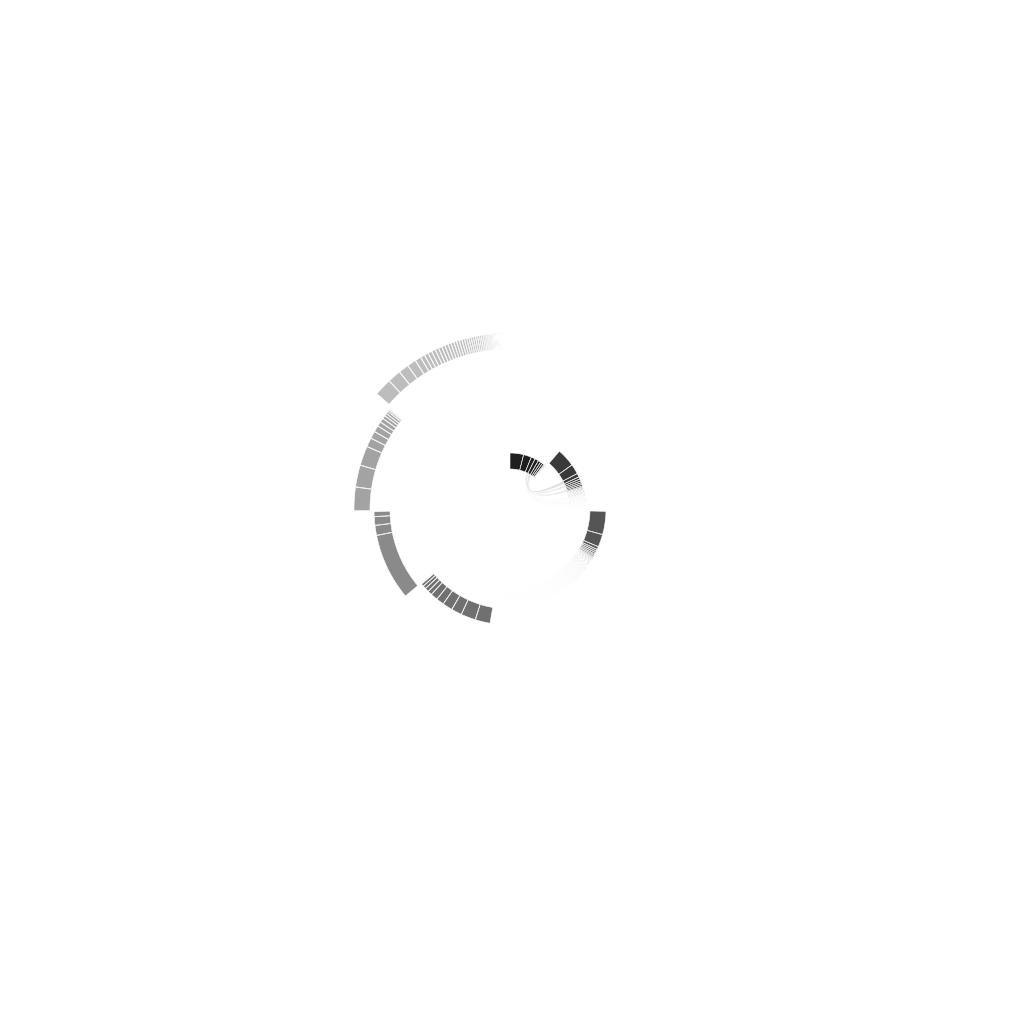

In [ ]:

layer_cols = [
    "rxnCategory",
    "rxnSubcategory",
    "reaction_class",
    "problemCategory",
    "solutionCat_L1",
    "solutionCat_L2",
    "solution_category",
]

missing = [c for c in layer_cols if c not in all_data.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Clean + keep complete paths
df = all_data[layer_cols].dropna().copy()
for c in layer_cols:
    df[c] = df[c].astype(str).str.strip()
df = df[(df[layer_cols] != "").all(axis=1)].copy()

print(f"Rows used: {len(df)}")

# Build weighted links for each adjacent layer
pair_weights = {}
for i in range(len(layer_cols) - 1):
    src, tgt = layer_cols[i], layer_cols[i + 1]
    agg = (
        df.groupby([src, tgt], dropna=False)
        .size()
        .reset_index(name="w")
        .sort_values([src, tgt])
        .reset_index(drop=True)
    )
    pair_weights[(src, tgt)] = agg

# Collect nodes and sizes
nodes_by_layer = defaultdict(list)
node_sizes = {}
for col in layer_cols:
    counts = df[col].value_counts()
    for lbl, n in counts.items():
        nid = f"{col}::{lbl}"
        nodes_by_layer[col].append(nid)
        node_sizes[nid] = int(n)

for col in layer_cols:
    nodes_by_layer[col] = sorted(nodes_by_layer[col], key=lambda x: (-node_sizes[x], x))

# Build circle and one arc per node
gc = Gcircle(figsize=(10, 10))

# Radius bands (inner -> outer)
band_width = 40
r0 = 80
band_radii = {}
for i, col in enumerate(layer_cols):
    inner = r0 + i * band_width
    outer = inner + band_width - 8
    band_radii[col] = (inner, outer)

layer_colors = {
    "rxnCategory": "#1f1f1f",
    "rxnSubcategory": "#3a3a3a",
    "reaction_class": "#555555",
    "problemCategory": "#707070",
    "solutionCat_L1": "#8a8a8a",
    "solutionCat_L2": "#a3a3a3",
    "solution_category": "#bdbdbd",
}

# Add arcs
for col in layer_cols:
    for nid in nodes_by_layer[col]:
        label = nid.split("::", 1)[1]
        arc = Garc(
            arc_id=nid,
            size=max(node_sizes[nid], 1),
            interspace=0.2,
            raxis_range=band_radii[col],
            facecolor=layer_colors[col],
            edgecolor="white",
            linewidth=0.4,
            label=label,
            label_visible=False,
        )
        gc.add_garc(arc)

gc.set_garcs()

# Build per-edge local x-ranges on each arc (required by chord_plot)
# chord_plot expects tuples: (arc_id, edge_position1, edge_position2, raxis_position)
for (src_col, tgt_col), agg in pair_weights.items():
    src_cursor = defaultdict(float)
    tgt_cursor = defaultdict(float)
    max_w = max(int(agg["w"].max()), 1) if len(agg) else 1

    src_anchor = band_radii[src_col][1]
    tgt_anchor = band_radii[tgt_col][0]

    for _, row in agg.iterrows():
        s_lbl, t_lbl, w = row[src_col], row[tgt_col], int(row["w"])
        s_nid = f"{src_col}::{s_lbl}"
        t_nid = f"{tgt_col}::{t_lbl}"

        if s_nid not in node_sizes or t_nid not in node_sizes:
            continue

        s0 = src_cursor[s_nid]
        s1 = min(s0 + w, float(node_sizes[s_nid]))
        t0 = tgt_cursor[t_nid]
        t1 = min(t0 + w, float(node_sizes[t_nid]))

        src_cursor[s_nid] = s1
        tgt_cursor[t_nid] = t1

        if s1 <= s0 or t1 <= t0:
            continue

        gray = 0.85 - 0.55 * (w / max_w)
        link_color = (gray, gray, gray, 0.45)

        gc.chord_plot(
            (s_nid, s0, s1, src_anchor),
            (t_nid, t0, t1, tgt_anchor),
            facecolor=link_color,
            edgecolor="none",
            linewidth=0.0,
        )

# Optional layer legend text
for i, col in enumerate(layer_cols):
    gc.figure.text(0.02, 0.95 - i * 0.035, f"{i+1}. {col}", fontsize=9, color=layer_colors[col])

plt.title("Circular hierarchy with reaction_class→problems and solution layers", pad=20)
plt.show()

In [9]:
import pycircos as _pycircos
print('pycircos module:', getattr(_pycircos, '__file__', 'unknown'))
print('has Gcircle:', hasattr(_pycircos, 'Gcircle'))
print('has Garc:', hasattr(_pycircos, 'Garc'))

if not (hasattr(_pycircos, 'Gcircle') and hasattr(_pycircos, 'Garc')):
    from pycircos.pycircos import Gcircle, Garc
    print('fallback import from pycircos.pycircos succeeded')
else:
    print('top-level import exposes pyCircos classes')

pycircos module: /opt/miniconda3/envs/general/lib/python3.13/site-packages/pycircos/__init__.py
has Gcircle: False
has Garc: False
fallback import from pycircos.pycircos succeeded


In [68]:
# Single Sankey: chemistry hierarchy -> problems -> solutions (export SVG)

import numpy as np
import pandas as pd
import plotly.graph_objects as go

if "all_data" not in globals():
    all_data = pd.read_csv("all_reaction_data_w_metadata_unrolled_20260222.csv")

if "solution_category" not in all_data.columns and "solutionCategory" in all_data.columns:
    all_data = all_data.copy()
    all_data["solution_category"] = all_data["solutionCategory"]

flow_cols = [
    "rxnCategory",
    "rxnSubcategory",
    "reaction_class",
    "problemCategory",
    "solutionCat_L1",
    "solutionCat_L2",
    "solution_category",
]

missing = [c for c in flow_cols if c not in all_data.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# ---------- Data prep ----------
df = all_data[flow_cols].dropna().copy()
for c in flow_cols:
    df[c] = df[c].astype(str).str.strip()
df = df[(df[flow_cols] != "").all(axis=1)].copy()

# Filter out unwanted reaction categories
exclude_rxn_categories = {"Unrecognized", "Resolution"}
df = df[~df["rxnCategory"].isin(exclude_rxn_categories)].copy()

# Keep only reaction classes with strictly greater than N entries
min_reaction_class_count = 20  # set to None to disable
if min_reaction_class_count is not None:
    rxn_counts = df["reaction_class"].value_counts()
    keep_rxn = rxn_counts[rxn_counts > int(min_reaction_class_count)].index
    df = df[df["reaction_class"].isin(keep_rxn)].copy()

print(f"Rows used: {len(df)}")
print(f"Unique reaction_class used: {df['reaction_class'].nunique()}")

# ---------- Build weighted edges ----------
edges = []
for i in range(len(flow_cols) - 1):
    src, tgt = flow_cols[i], flow_cols[i + 1]
    agg = df.groupby([src, tgt]).size().reset_index(name="v")
    agg["src_level"] = src
    agg["tgt_level"] = tgt
    edges.append(agg)

edges_df = pd.concat(edges, ignore_index=True)

# ---------- Label formatting ----------
def format_label_for_level(level: str, label: str) -> str:
    if level in ["reaction_class", "rxnSubcategory", "rxnCategory"]:
        if "pretty_rxn_label" in globals():
            return pretty_rxn_label(label)
        return label
    if "pretty_label" in globals():
        return pretty_label(label)
    return label

# ---------- Build nodes ----------
node_ids = []
node_map = {}
node_raw_labels = []
node_base_labels = []

for lvl in flow_cols:
    vals = sorted(df[lvl].unique().tolist())
    for val in vals:
        nid = f"{lvl}::{val}"
        node_map[nid] = len(node_ids)
        node_ids.append(nid)
        node_raw_labels.append(val)
        node_base_labels.append(format_label_for_level(lvl, val))

source = []
target = []
value = []
for _, row in edges_df.iterrows():
    s_id = f"{row['src_level']}::{row[row['src_level']]}"
    t_id = f"{row['tgt_level']}::{row[row['tgt_level']]}"
    source.append(node_map[s_id])
    target.append(node_map[t_id])
    value.append(int(row["v"]))

# Add per-node frequencies and append in parentheses to labels
n_nodes = len(node_ids)
incoming = np.zeros(n_nodes, dtype=int)
outgoing = np.zeros(n_nodes, dtype=int)
for s, t, v in zip(source, target, value):
    outgoing[s] += int(v)
    incoming[t] += int(v)
node_counts = np.maximum(incoming, outgoing)
node_labels = [f"{lbl} ({int(cnt)})" for lbl, cnt in zip(node_base_labels, node_counts)]

# ---------- Styling ----------
node_level_color = {
    "rxnCategory": "#4f4f4f",
    "rxnSubcategory": "#6b6b6b",
    "reaction_class": "#868686",
    "problemCategory": "#5a5a5a",
    "solutionCat_L1": "#7a7a7a",
    "solutionCat_L2": "#9a9a9a",
    "solution_category": "#b7b7b7",
}
node_colors = [node_level_color.get(n.split("::", 1)[0], "#BBBBBB") for n in node_ids]

max_v = max(value) if value else 1
link_colors = [f"rgba(120,120,120,{0.20 + 0.45*(v/max_v):.3f})" for v in value]

# ---------- Plot ----------
fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",
            node=dict(
                pad=10,
                thickness=16,
                line=dict(color="#1f77b4", width=2.8),
                label=node_labels,
                color=node_colors,
                customdata=node_raw_labels,
                hovertemplate="%{customdata}<extra></extra>",
            ),
            link=dict(
                source=source,
                target=target,
                value=value,
                color=link_colors,
                hovertemplate="Count: %{value}<extra></extra>",
            ),
        )
    ]
)

# Post-construction node border update (per-node loop)
# This is intentionally done after go.Figure creation to avoid relying on constructor-time coercion.
node_border_level_color = {
    "rxnCategory": "#1f77b4",
    "rxnSubcategory": "#17becf",
    "reaction_class": "#2ca02c",
    "problemCategory": "#ff7f0e",
    "solutionCat_L1": "#d62728",
    "solutionCat_L2": "#9467bd",
    "solution_category": "#8c564b",
}

node_line_colors = ["#1f77b4"] * len(node_ids)
for i, node_id in enumerate(node_ids):
    level = node_id.split("::", 1)[0]
    node_line_colors[i] = node_border_level_color.get(level, "#4d4d4d")

fig.data[0].node.line.color = node_line_colors
fig.data[0].node.line.width = 2.8

# Export sizing: max width 7 inches @ 300 dpi
width_in = 7.0
height_in = 7
dpi = 300
width_px = int(width_in * dpi)
height_px = int(height_in * dpi)

fig.update_layout(
    title="Single Sankey: rxnCategory → rxnSubcategory → reaction_class → problems → solutions",
    width=width_px,
    height=height_px,
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(l=20, r=20, t=58, b=20),
)



# Note: bbox_inches/pad_inches are Matplotlib options and are not supported by Plotly write_image
out_path = "single_sankey.svg"
fig.write_image(out_path, width=width_px, height=height_px, scale=1)
print(f"Saved: {out_path} ({width_in}in x {height_in}in @ {dpi} dpi)")

Rows used: 8370
Unique reaction_class used: 79
Saved: single_sankey.svg (7.0in x 7in @ 300 dpi)


In [ ]:
# Year-first Sankey (publication-focused): year -> chemistry -> problem -> solution
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.colors import sample_colorscale
import sys
sys.path.append("..")
from figure4_new2.figure4_helper import pretty_label, pretty_rxn_label, wrap_label, nlines

if "all_data" not in globals():
    all_data = pd.read_csv("all_reaction_data_w_metadata_unrolled_20260222.csv")

df_year = all_data.copy()

# Normalize possible alias
if "solution_category" not in df_year.columns and "solutionCategory" in df_year.columns:
    df_year["solution_category"] = df_year["solutionCategory"]

# Detect year column
year_col = None
for c in ["pub_year", "publication_year", "year", "Year", "article_year"]:
    if c in df_year.columns:
        year_col = c
        break
if year_col is None:
    raise ValueError("No year column found. Tried: pub_year, publication_year, year, Year, article_year")

# Convert to integer years (using all distinct years as bins)
df_year[year_col] = pd.to_numeric(df_year[year_col], errors="coerce")
df_year = df_year[df_year[year_col].notna()].copy()
df_year[year_col] = df_year[year_col].astype(int)

# Keep plausible publication years only
df_year = df_year[(df_year[year_col] >= 1900) & (df_year[year_col] <= 2100)].copy()

flow_cols = [
    year_col,
    "rxnCategory",
    "rxnSubcategory",
    "reaction_class",
    "problemCategory",
    "solutionCat_L1",
    "solutionCat_L2",
    "solution_category",
]
missing = [c for c in flow_cols if c not in df_year.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Optional publication-oriented pruning for readability
exclude_rxn_categories = {"Unrecognized", "Resolution"}
min_reaction_class_count = 20  # set None to disable

# Clean + complete paths
df_flow = df_year[flow_cols].dropna().copy()
for c in flow_cols:
    df_flow[c] = df_flow[c].astype(str).str.strip()
df_flow = df_flow[(df_flow[flow_cols] != "").all(axis=1)].copy()

if "rxnCategory" in df_flow.columns and exclude_rxn_categories:
    df_flow = df_flow[~df_flow["rxnCategory"].isin(exclude_rxn_categories)].copy()

if min_reaction_class_count is not None:
    rc_counts = df_flow["reaction_class"].value_counts()
    keep_rc = rc_counts[rc_counts > int(min_reaction_class_count)].index
    df_flow = df_flow[df_flow["reaction_class"].isin(keep_rc)].copy()

# Use exact years as first-layer bins (not ranges)
years_sorted = sorted(pd.to_numeric(df_flow[year_col], errors="coerce").dropna().astype(int).unique().tolist())
df_flow[year_col] = pd.Categorical(
    pd.to_numeric(df_flow[year_col], errors="coerce").astype(int),
    categories=years_sorted,
    ordered=True,
).astype(str)

print(f"Rows used: {len(df_flow):,}")
print(f"Year bins (exact years): {years_sorted}")
print(f"Unique reaction classes: {df_flow['reaction_class'].nunique()}")

# Year color map for links
if len(years_sorted) == 1:
    year_scale_pos = [0.5]
else:
    year_scale_pos = np.linspace(0.05, 0.95, len(years_sorted)).tolist()
year_rgb = sample_colorscale("magma", year_scale_pos)
year_to_rgb = {y: c for y, c in zip(years_sorted, year_rgb)}

def rgb_to_rgba(rgb_str, alpha=0.45):
    vals = rgb_str.strip()[4:-1]
    return f"rgba({vals},{alpha})"

year_to_rgba = {y: rgb_to_rgba(c, alpha=0.45) for y, c in year_to_rgb.items()}

# Build weighted edges between adjacent levels, split by year for all layers
edges = []
for i in range(len(flow_cols) - 1):
    src, tgt = flow_cols[i], flow_cols[i + 1]
    if src == year_col:
        agg = df_flow.groupby([src, tgt]).size().reset_index(name="v")
        agg["link_year"] = pd.to_numeric(agg[src], errors="coerce").astype(int)
    else:
        agg = df_flow.groupby([year_col, src, tgt]).size().reset_index(name="v")
        agg["link_year"] = pd.to_numeric(agg[year_col], errors="coerce").astype(int)

    agg["src_level"] = src
    agg["tgt_level"] = tgt
    agg = agg.rename(columns={src: "src", tgt: "tgt"})
    edges.append(agg[["link_year", "src_level", "tgt_level", "src", "tgt", "v"]])

edges_df = pd.concat(edges, ignore_index=True)

# Build nodes
node_ids, node_map, node_raw = [], {}, []
for lvl in flow_cols:
    vals = sorted(df_flow[lvl].astype(str).unique().tolist())
    if lvl == year_col:
        vals = [str(y) for y in years_sorted if str(y) in set(vals)]
    for val in vals:
        nid = f"{lvl}::{val}"
        node_map[nid] = len(node_ids)
        node_ids.append(nid)
        node_raw.append(val)

source, target, value, link_colors, link_years = [], [], [], [], []
for _, row in edges_df.iterrows():
    s_id = f"{row['src_level']}::{row['src']}"
    t_id = f"{row['tgt_level']}::{row['tgt']}"
    source.append(node_map[s_id])
    target.append(node_map[t_id])
    value.append(int(row["v"]))

    y = int(row["link_year"])
    link_years.append(str(y))
    link_colors.append(year_to_rgba.get(y, "rgba(120,120,120,0.35)"))

# Add node counts to labels
n_nodes = len(node_ids)
incoming = np.zeros(n_nodes, dtype=int)
outgoing = np.zeros(n_nodes, dtype=int)
for s, t, v in zip(source, target, value):
    outgoing[s] += int(v)
    incoming[t] += int(v)
node_counts = np.maximum(incoming, outgoing)
node_labels = [f"{pretty_label(pretty_rxn_label(lbl))} ({int(cnt)})" for lbl, cnt in zip(node_raw, node_counts)]

# Keep nodes neutral so year-colored links stand out
level_color = {
    year_col: "#222222",
    "rxnCategory": "#4a4a4a",
    "rxnSubcategory": "#6a6a6a",
    "reaction_class": "#868686",
    "problemCategory": "#9c9c9c",
    "solutionCat_L1": "#b0b0b0",
    "solutionCat_L2": "#c2c2c2",
    "solution_category": "#d0d0d0",
}
node_colors = [level_color.get(n.split("::", 1)[0], "#BBBBBB") for n in node_ids]

fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",
            node=dict(
                pad=10,
                thickness=15,
                line=dict(color="#4d4d4d", width=0.8),
                label=node_labels,
                color=node_colors,
                customdata=node_raw,
                hovertemplate="%{customdata}<extra></extra>",
            ),
            link=dict(
                source=source,
                target=target,
                value=value,
                color=link_colors,
                hovertemplate="Year: %{customdata}<br>Count: %{value}<extra></extra>",
                customdata=link_years,
            ),
        )
    ]
)

# Publication sizing: 7 in width @ 300 dpi
width_in, height_in, dpi = 7.0, 9, 300
width_px, height_px = int(width_in * dpi), int(height_in * dpi)

fig.update_layout(
    title=f"Year-colored Sankey ({year_col} as first layer)",
    width=width_px,
    height=height_px,
    font=dict(size=9, color="black"),
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(l=15, r=15, t=42, b=12),
)

fig.show()

# Optional export
# out_path = "year_colored_links_sankey.svg"
# fig.write_image(out_path, width=width_px, height=height_px, scale=1)
print(f"Saved: {out_path} ({width_in}in x {height_in}in @ {dpi} dpi)")

Rows used: 10,171
Year bins (exact years): [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Unique reaction classes: 82


Saved: year_colored_links_sankey.svg (7.0in x 9in @ 300 dpi)


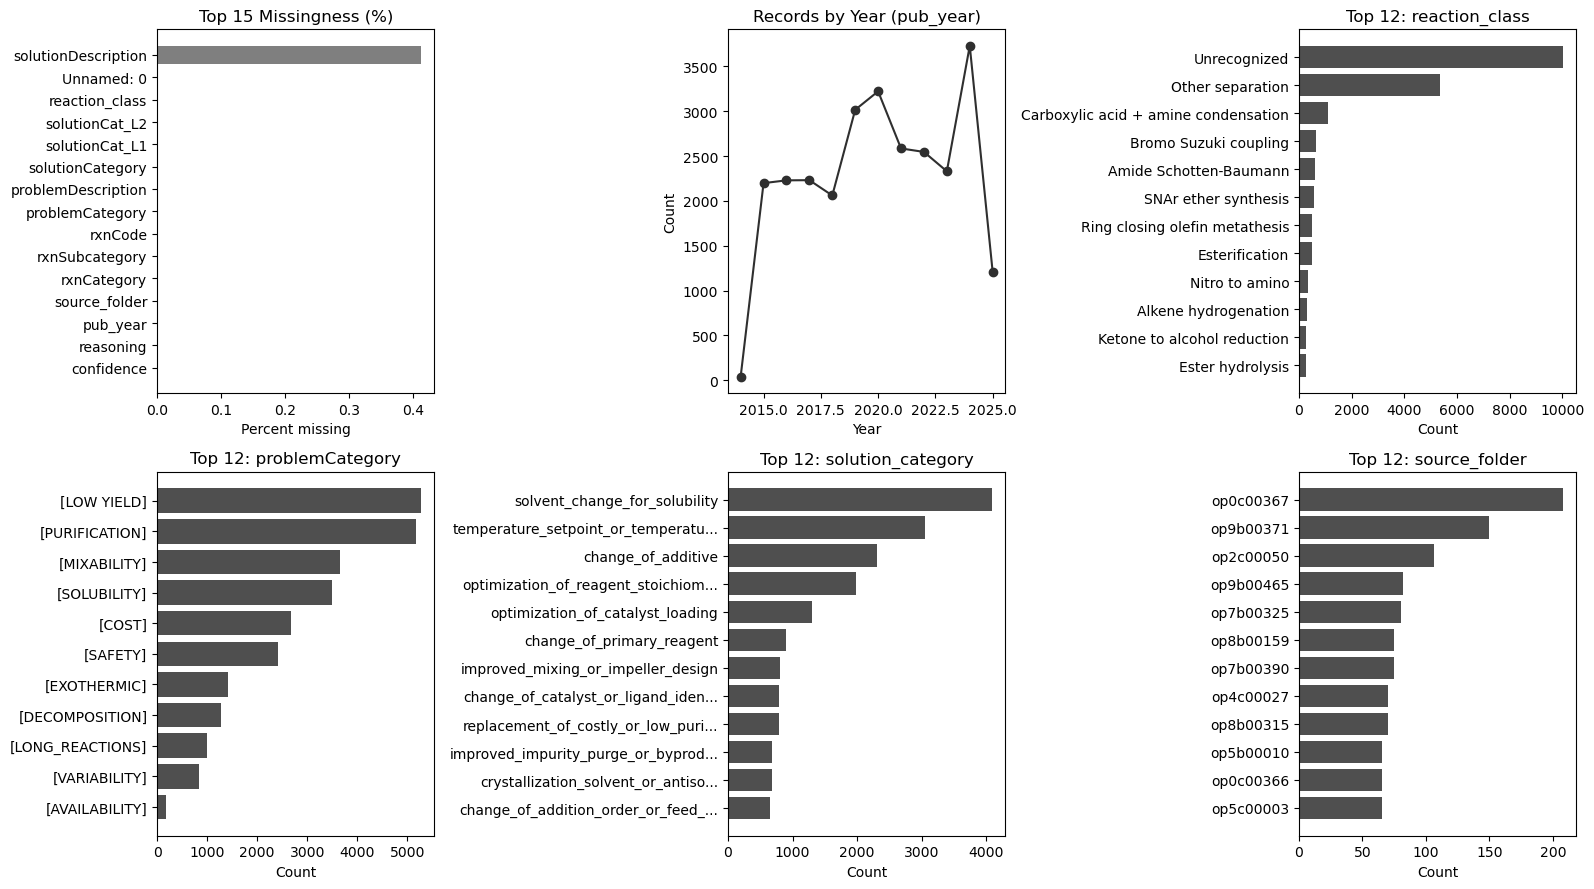

Rows: 27,392 | Columns: 18
Available core categorical columns: ['reaction_class', 'rxnCategory', 'rxnSubcategory', 'problemCategory', 'solutionCat_L1', 'solutionCat_L2', 'solution_category', 'source_folder']


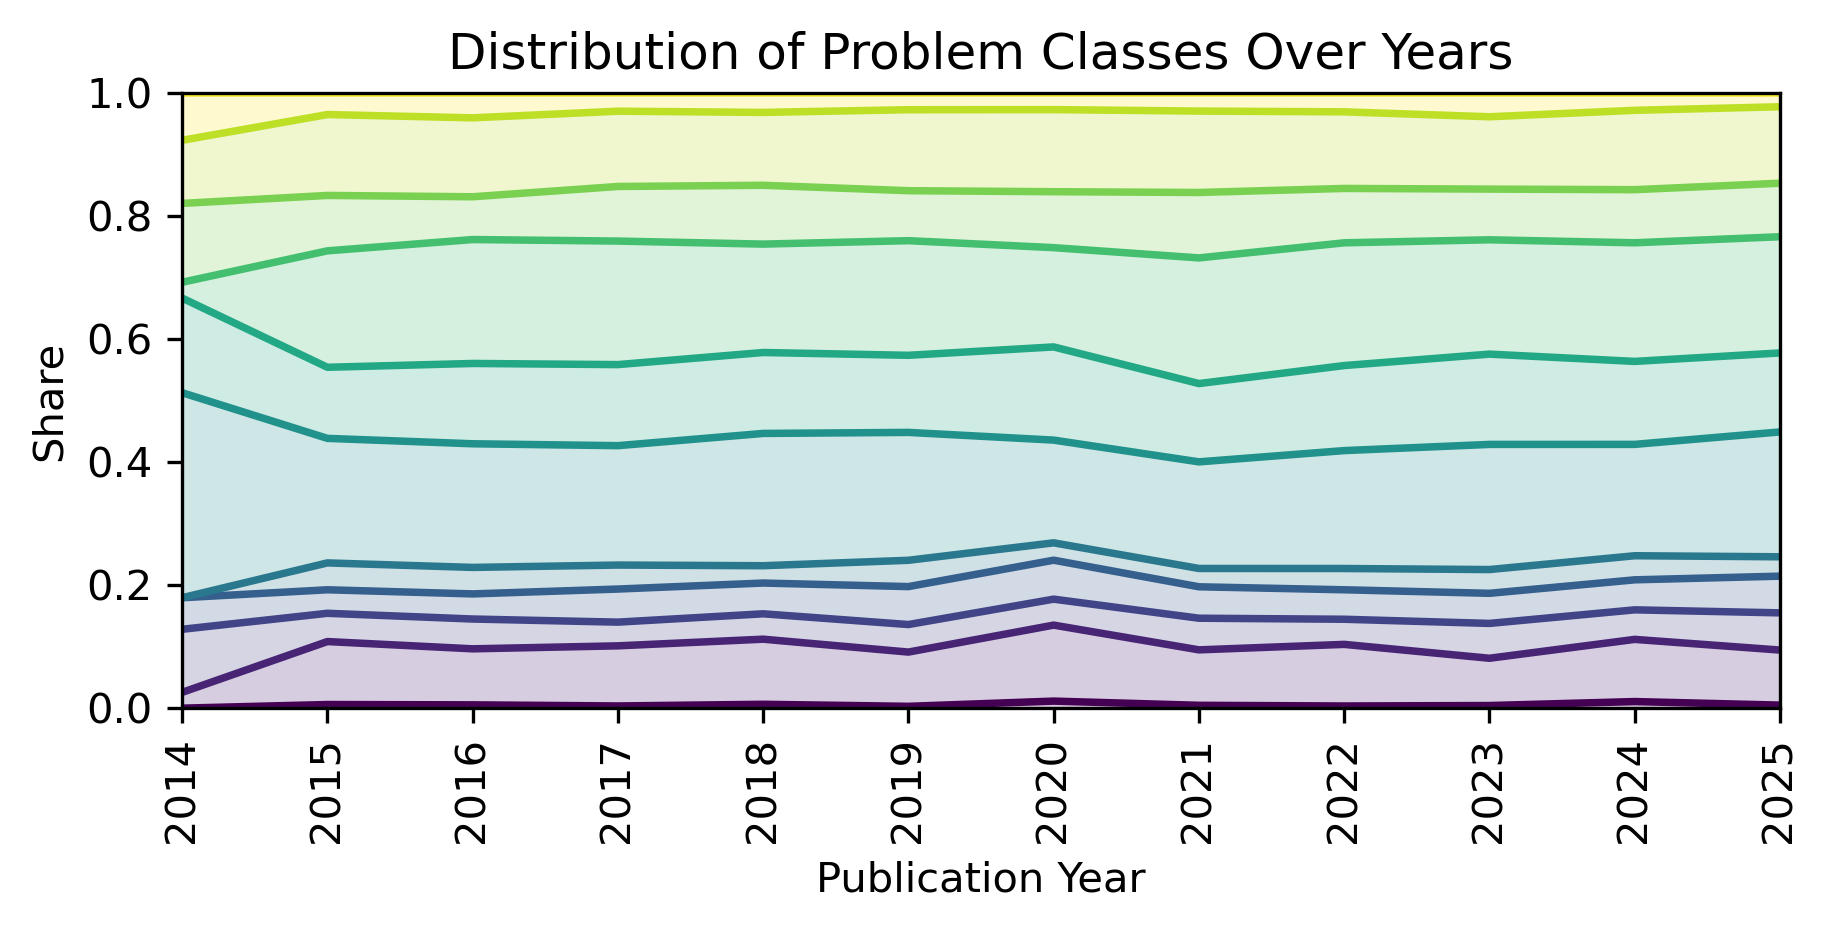

In [2]:
# General trends overview for all_data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "all_data" not in globals():
    all_data = pd.read_csv("all_reaction_data_w_metadata_unrolled_20260222.csv")

df = all_data.copy()

# Normalize potential alias for solution column
if "solution_category" not in df.columns and "solutionCategory" in df.columns:
    df["solution_category"] = df["solutionCategory"]

# Candidate columns commonly used in this project
cat_candidates = [
    "reaction_class",
    "rxnCategory",
    "rxnSubcategory",
    "problemCategory",
    "solutionCat_L1",
    "solutionCat_L2",
    "solution_category",
    "source_folder",
]
present_cats = [c for c in cat_candidates if c in df.columns]

# Try to infer a year column
year_col = None
for c in ["year", "publication_year", "pub_year", "Year", "article_year"]:
    if c in df.columns:
        year_col = c
        break

# Convert year to numeric if available
if year_col is not None:
    yr = pd.to_numeric(df[year_col], errors="coerce")
    year_counts = yr.dropna().astype(int).value_counts().sort_index()
    year_counts = year_counts[(year_counts.index >= 1900) & (year_counts.index <= 2100)]
else:
    year_counts = pd.Series(dtype=int)

# Missingness summary
missing_pct = (df.isna().mean().sort_values(ascending=False) * 100).head(15)

# Build figure layout
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

# 1) Missingness
ax = axes[0]
if len(missing_pct) > 0:
    ax.barh(missing_pct.index[::-1], missing_pct.values[::-1], color="#7f7f7f")
    ax.set_title("Top 15 Missingness (%)")
    ax.set_xlabel("Percent missing")
else:
    ax.text(0.5, 0.5, "No columns", ha="center", va="center")
    ax.set_title("Missingness")

# 2) Year trend
ax = axes[1]
if len(year_counts) > 0:
    ax.plot(year_counts.index, year_counts.values, marker="o", linewidth=1.5, color="#2f2f2f")
    ax.set_title(f"Records by Year ({year_col})")
    ax.set_xlabel("Year")
    ax.set_ylabel("Count")
else:
    ax.text(0.5, 0.5, "No year column found", ha="center", va="center")
    ax.set_title("Records by Year")

# Helper for top-N bar charts
def plot_top(ax, col, n=12):
    s = df[col].dropna().astype(str).str.strip()
    s = s[s != ""]
    vc = s.value_counts().head(n)
    if len(vc) == 0:
        ax.text(0.5, 0.5, f"No data in {col}", ha="center", va="center")
        ax.set_title(f"Top {col}")
        return
    labels = [x if len(x) <= 36 else x[:33] + "..." for x in vc.index]
    ax.barh(labels[::-1], vc.values[::-1], color="#4f4f4f")
    ax.set_title(f"Top {n}: {col}")
    ax.set_xlabel("Count")

# 3-6) Core categorical trends
plot_slots = [
    "reaction_class",
    "problemCategory",
    "solution_category",
    "source_folder",
]
for i, col in enumerate(plot_slots, start=2):
    ax = axes[i]
    if col in df.columns:
        plot_top(ax, col, n=12)
    else:
        ax.text(0.5, 0.5, f"Column not found:\n{col}", ha="center", va="center")
        ax.set_title(col)

plt.tight_layout()
plt.show()

print(f"Rows: {len(df):,} | Columns: {df.shape[1]:,}")
print("Available core categorical columns:", present_cats)


def plot_problem_distribution_stacked_lines(
    df,
    *,
    normalize=True,
    problem_categories=None,
    years_sorted=None,
    color_map=None,
    ax=None,
    linewidth=1.8,
    alpha=0.22,
    year_col="pub_year",
):
    """
    Stacked line plot (with optional normalized shares) of problem-category distribution by year.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns: 'problemCategory' and year_col (default 'pub_year').
    normalize : bool, default True
        If True, plot yearly proportions (sum to 1). If False, plot raw counts.
    problem_categories : list[str] | None
        Category order. If None, inferred from df.
    years_sorted : list[int] | None
        Year order. If None, inferred from df.
    color_map : dict[str, color] | None
        Mapping from category -> matplotlib color. If None, generated from viridis.
    ax : matplotlib.axes.Axes | None
        Existing axes to draw on. If None, creates a new figure/axes.
    """
    required_cols = {"problemCategory", year_col}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    data = df[df["problemCategory"].notna() & df[year_col].notna()].copy()
    if len(data) == 0:
        raise ValueError(f"No valid rows with non-null problemCategory and {year_col}.")

    data[year_col] = pd.to_numeric(data[year_col], errors="coerce")
    data = data[data[year_col].notna()].copy()
    data[year_col] = data[year_col].astype(int)

    if problem_categories is None:
        problem_categories = sorted(data["problemCategory"].astype(str).str.strip().unique())
    if years_sorted is None:
        years_sorted = sorted(data[year_col].unique())

    problem_year_counts = (
        data.groupby([year_col, "problemCategory"]).size()
        .unstack(fill_value=0)
        .reindex(index=years_sorted, columns=problem_categories, fill_value=0)
    )

    y = problem_year_counts.to_numpy(dtype=float)
    if normalize:
        row_sums = y.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        y = y / row_sums

    if color_map is None:
        cmap = plt.get_cmap("viridis", len(problem_categories))
        color_map = {cat: cmap(i) for i, cat in enumerate(problem_categories)}

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(6.2, 3.2), dpi=300)
        created_fig = True

    x = np.array(years_sorted)
    ax.stackplot(
        x,
        y.T,
        labels=problem_categories,
        colors=[color_map[c] for c in problem_categories],
        alpha=alpha,
    )

    cumulative = np.cumsum(y, axis=1)
    for i, cat in enumerate(problem_categories):
        ax.plot(
            x,
            cumulative[:, i],
            color=color_map[cat],
            linewidth=linewidth,
        )

    ax.set_xlim(x.min(), x.max())
    ax.set_xticks(x)
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Publication Year")
    ax.set_ylabel("Share" if normalize else "Count")
    ax.set_title("Distribution of Problem Classes Over Years")
    if normalize:
        ax.set_ylim(0, 1)

    if created_fig:
        plt.tight_layout()

    return ax, problem_year_counts


if year_col is not None and "problemCategory" in df.columns:
    ax_stacked, problem_year_counts = plot_problem_distribution_stacked_lines(
        df,
        normalize=True,
        year_col=year_col,
    )
    plt.show()
else:
    print("Skipped stacked problem-year plot (missing year or problemCategory column).")